# 載入資料

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris

iris = load_iris()
# iris

In [ ]:
# 使用 pandas 整理資料集
df = pd.DataFrame(iris["data"], columns=iris["feature_names"])
df["target"] = iris["target"]
df # 150 rows × 5 columns

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


# 遺漏值處理

In [ ]:
df.info()
print('='*50)
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


*   sepal length（花萼長度）
*   sepal width（花萼寬度）
*   petal length（花瓣長度）
*   petal width（花瓣寬度）

In [ ]:
# import missingno as msno

# msno.bar(df)
# # msno.matrix(df)

In [ ]:
# # 刪除
# df.dropna(inplace=True) # 刪除含缺失值的行,row（如果缺失值數量少）
# df.dropna(axis=1, inplace=True) # 刪除含缺失值的列,column（如果某列缺失值過多）

In [ ]:
# # 補值
# df.fillna(0, inplace=True) # 填0
# df.fillna(df.mean(), inplace=True) # 填平均值
# df.fillna(df.median(), inplace=True) # 填中位數
# df.fillna(df.mode().iloc[0], inplace=True) # 填眾數
# df.fillna(method='ffill', inplace=True)  # 用前一個值
# df.fillna(method='bfill', inplace=True)  # 用後一個值

In [ ]:
df.describe(include='all')

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


# Label分類數值

In [ ]:
from sklearn.preprocessing import LabelEncoder

use_columns = ['target']
df_copy = df.copy()
label_encoder = LabelEncoder()
for col in use_columns:
    df_copy[col + '_encoded'] = label_encoder.fit_transform(df[col])
    original_values = df_copy[col].unique()
    encoded_values = df_copy[col + '_encoded'].unique()
    print(f"Original values for column '{col}': {original_values}")
    print(f"Encoded values for column '{col}': {encoded_values}")
    print()

Original values for column 'target': [0 1 2]
Encoded values for column 'target': [0 1 2]



In [ ]:
le = LabelEncoder()
df["target"] = le.fit_transform(df["target"])
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


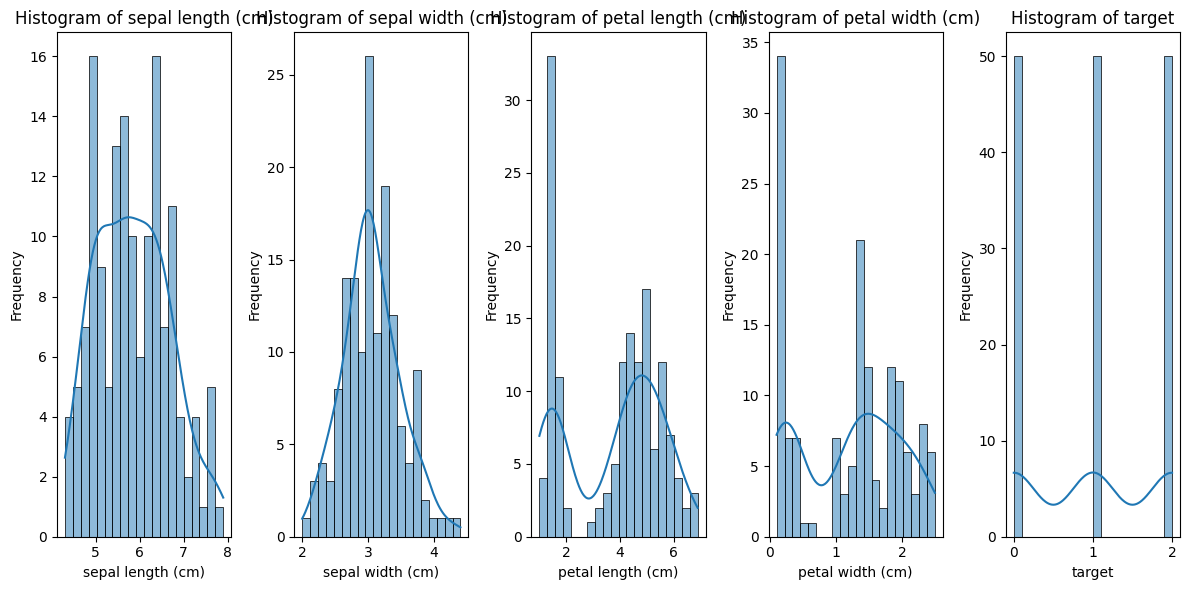

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_columns = df.select_dtypes(include=['int','float']).columns # 數值欄位

plt.figure(figsize=(12, 6))
for i, column in enumerate(numerical_columns, 1):
    plt.subplot(1, 5, i) # 1x5 子圖
    sns.histplot(df[column], bins=20, kde=True)
    plt.title(f'Histogram of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

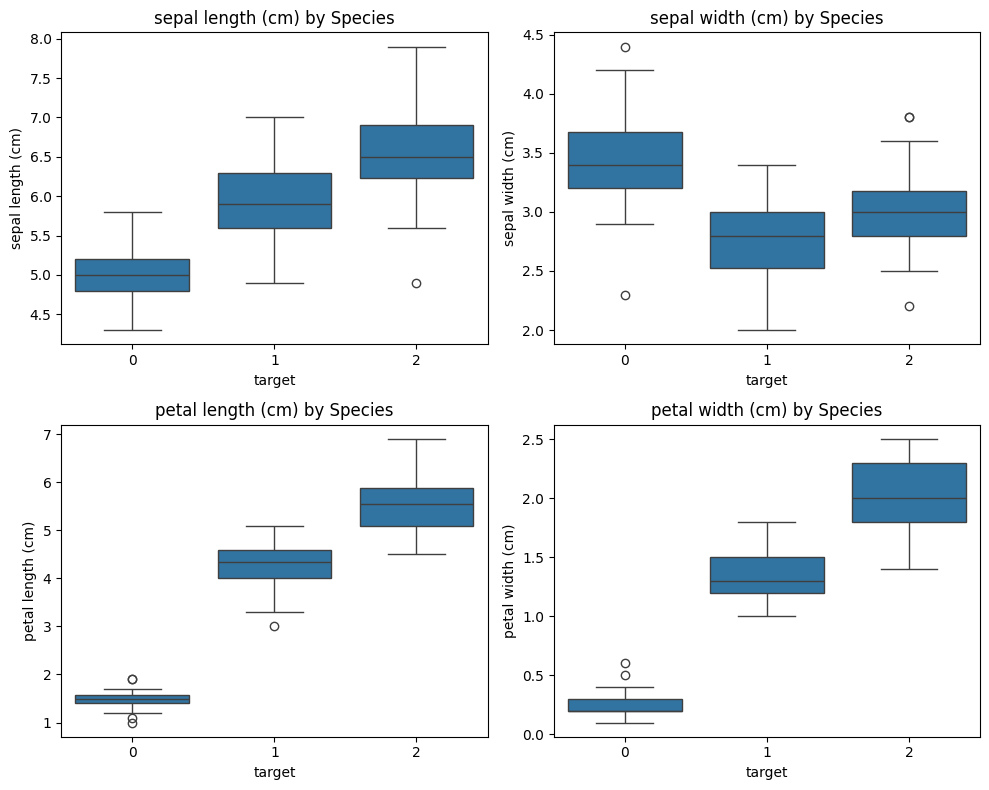

In [ ]:
# 繪製箱型圖
plt.figure(figsize=(10, 8))

for i, feature in enumerate(iris.feature_names, 1):
    plt.subplot(2, 2, i)  # 2x2 子圖
    sns.boxplot(data=df, x='target', y=feature)
    plt.title(f"{feature} by Species")

plt.tight_layout()
plt.show()

In [ ]:
# # 散點圖
# sns.pairplot(df, hue='target')

# 熱力圖

In [ ]:
correlation = df.corr()
# correlation = df.corr().abs()
top_features = correlation['target'].sort_values(ascending=False)
top_features

,target
target,1.000000
petal width (cm),0.956547
petal length (cm),0.949035
sepal length (cm),0.782561
sepal width (cm),-0.426658


使用 df.corr() 方法時，會返回一個變數之間的 相關係數矩陣。每個元素代表了兩個變數之間的相關性，通常範圍在 -1 到 1 之間
*   1 表示兩個變數完全正相關。
*   -1 表示兩個變數完全負相關。
*   0 表示兩個變數之間沒有線性關係。

相關性解釋：

*   正相關：當一個變數增加時，另一個變數也隨之增加。
*   負相關：當一個變數增加時，另一個變數隨之減少。
*   無相關：兩個變數之間的變化不具有任何規律。





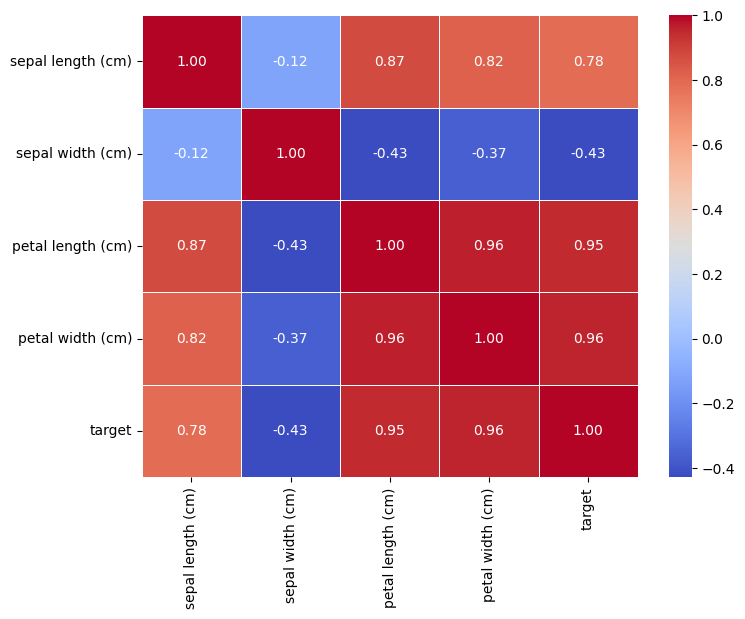

In [ ]:
corr_matrix = df.corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.show()

# 切割資料

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)
print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)
# print('='*30)
# # 查看全部資料的類別比例
# print(pd.Series(y).value_counts(normalize=True))
# # 查看訓練集標籤的分佈
# print(pd.Series(y_train).value_counts(normalize=True))
# # 查看測試集標籤的分佈
# print(pd.Series(y_test).value_counts(normalize=True))

X_train: (75, 4)
X_test: (75, 4)
y_train: (75,)
y_test: (75,)


In [ ]:
from collections import Counter

print(f"Training target : {Counter(y_train)}")
print(f"Testing target : {Counter(y_test)}")

Training target : Counter({0: 25, 1: 25, 2: 25})
Testing target : Counter({0: 25, 2: 25, 1: 25})


# 縮放特徵

對 訓練集 進行 特徵縮放（Feature Scaling），通常有兩種方法：

1.   標準化（Standardization, Z-score）
*   清單項目使用 StandardScaler()，將數據轉換為 均值為 0，標準差為 1 的標準正態分佈。
*   適用於大多數機器學習演算法（如 SVM、KNN、線性回歸等）。

2.   最小-最大縮放（Min-Max Scaling）
*   清單項目使用 MinMaxScaler()，將數據壓縮到 [0,1] 區間。
*   清單項目適用於 神經網路 或 數據範圍已知的應用。

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# 只對訓練集 X_train 做 fit，然後 transform
X_train_scaled = scaler.fit_transform(X_train)

# 測試集 X_test 只做 transform（不能 fit，避免資料洩漏）
X_test_scaled = scaler.transform(X_test)

# 轉回 DataFrame 方便查看
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

X_train_scaled_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,7.500000e+01,7.500000e+01,7.500000e+01,7.500000e+01
mean,9.888386e-16,2.202312e-15,1.483258e-15,2.279658e-16
std,1.006734e+00,1.006734e+00,1.006734e+00,1.006734e+00
min,-1.761329e+00,-2.235370e+00,-1.499886e+00,-1.413828e+00
25%,-8.596247e-01,-6.129241e-01,-1.277241e+00,-1.157080e+00
50%,-7.063350e-02,-7.210872e-02,2.256137e-01,1.266626e-01
75%,6.056447e-01,4.687067e-01,7.265651e-01,8.969080e-01
max,2.296340e+00,2.956457e+00,1.728468e+00,1.667153e+00


# 模型建立

**DecisionTreeClassifier**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

# 評估

Train Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        25
           1       1.00      1.00      1.00        25
           2       1.00      1.00      1.00        25

    accuracy                           1.00        75
   macro avg       1.00      1.00      1.00        75
weighted avg       1.00      1.00      1.00        75

Test Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        25
           1       0.75      0.96      0.84        25
           2       0.94      0.68      0.79        25

    accuracy                           0.88        75
   macro avg       0.90      0.88      0.88        75
weighted avg       0.90      0.88      0.88        75

Train AUC: 1.000000
Test AUC: 0.910000


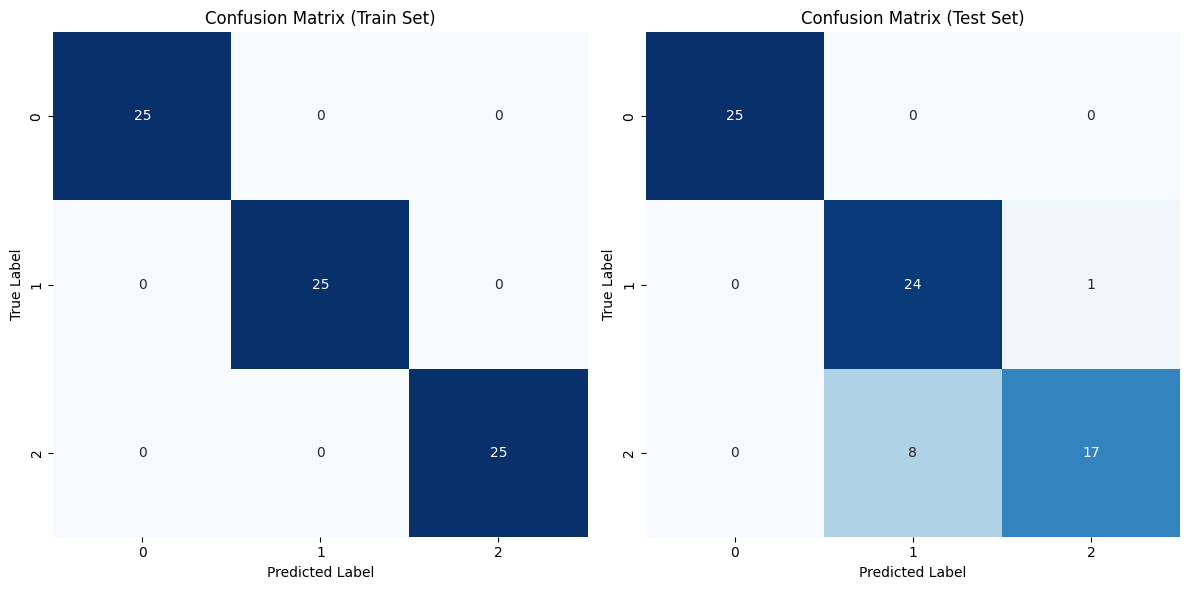

In [ ]:
from sklearn.metrics import roc_auc_score ,roc_curve ,classification_report ,confusion_matrix

def evaluate_model(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    print("Train Set:")
    print(classification_report(y_train, y_train_pred))
    print("Test Set:")
    print(classification_report(y_test, y_test_pred))

    # 計算 AUC（適用於多分類）
    train_auc = roc_auc_score(y_train, model.predict_proba(X_train), multi_class='ovr')
    test_auc = roc_auc_score(y_test, model.predict_proba(X_test), multi_class='ovr')

    # 計算 AUC（二元分類）
    # train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
    # test_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

    print(f"Train AUC: {train_auc:.6f}")
    print(f"Test AUC: {test_auc:.6f}")

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    sns.heatmap(confusion_matrix(y_train, y_train_pred), annot=True, cmap='Blues', fmt='d', cbar=False)
    plt.title('Confusion Matrix (Train Set)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.subplot(1, 2, 2)
    sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, cmap='Blues', fmt='d', cbar=False)
    plt.title('Confusion Matrix (Test Set)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()
evaluate_model(dt, X_train, y_train, X_test, y_test)

**LogisticRegression**

In [ ]:
from sklearn.linear_model import LogisticRegression

# lr = LogisticRegression(random_state=42)
# lr.fit(X_train, y_train)

In [ ]:
# evaluate_model(lr, X_train, y_train, X_test, y_test)

X_train: (75, 2)
X_test: (75, 2)
y_train: (75,)
y_test: (75,)


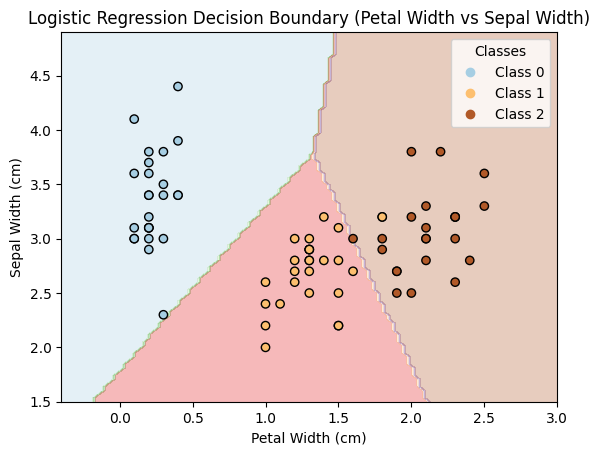

In [ ]:
# Logistic Regression 決策邊界
# 只能在 2D 空間畫決策邊界，所以 X_train 必須只有 兩個特徵（否則需要降維）。
# 只選擇 'petal width (cm)' 和 'sepal width (cm)'
use_columns = ['petal width (cm)', 'sepal width (cm)']
X = df[use_columns]
y = df["target"]

# 切分訓練集和測試集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

# 轉成 NumPy 陣列（確保與 sklearn 兼容）
X_train_2D = X_train.values
X_test_2D = X_test.values

# 訓練 Logistic Regression
lr = LogisticRegression(random_state=42)
lr.fit(X_train_2D, y_train)

# 建立網格點
x_min, x_max = X_train_2D[:, 0].min() - 0.5, X_train_2D[:, 0].max() + 0.5
y_min, y_max = X_train_2D[:, 1].min() - 0.5, X_train_2D[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

# 預測每個網格點的分類
Z = lr.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 畫出決策邊界
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Paired)

# 畫出訓練資料點
scatter = plt.scatter(X_train_2D[:, 0], X_train_2D[:, 1], c=y_train, edgecolors='k', cmap=plt.cm.Paired)

# 根據 y_train 的唯一值來設置圖例標籤
unique_classes = np.unique(y_train)
labels = [f"Class {i}" for i in unique_classes]

plt.legend(handles=scatter.legend_elements()[0], labels=labels, title="Classes")
plt.xlabel('Petal Width (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Logistic Regression Decision Boundary (Petal Width vs Sepal Width)')
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Train Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        25
           1       0.92      0.96      0.94        25
           2       0.96      0.92      0.94        25

    accuracy                           0.96        75
   macro avg       0.96      0.96      0.96        75
weighted avg       0.96      0.96      0.96        75

Test Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        25
           1       0.88      0.88      0.88        25
           2       0.88      0.88      0.88        25

    accuracy                           0.92        75
   macro avg       0.92      0.92      0.92        75
weighted avg       0.92      0.92      0.92        75

Train AUC: 0.988533
Test AUC: 0.980000


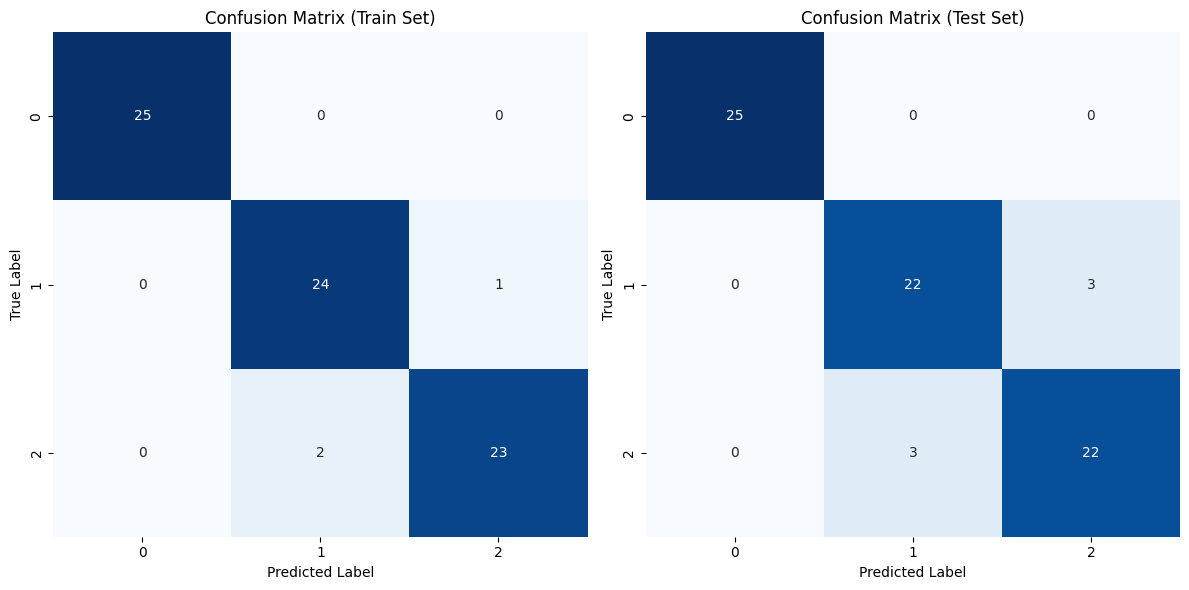

In [ ]:
evaluate_model(lr, X_train, y_train, X_test, y_test)